# Distribution recipe -- every sampling axis in the pipeline, side by side

Not the effect on a rose or a layout -- just the shape itself, and why that shape. One
reference sheet for every random draw currently in the design.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, lognorm, norm

sys.path.insert(0, str(Path("..") / "Monte_Carlo_v2"))
import von_mises_climate as vm

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

/opt/anaconda3/envs/wesl_jul_31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Discrete axes -- farm count, spacing, turbine choice

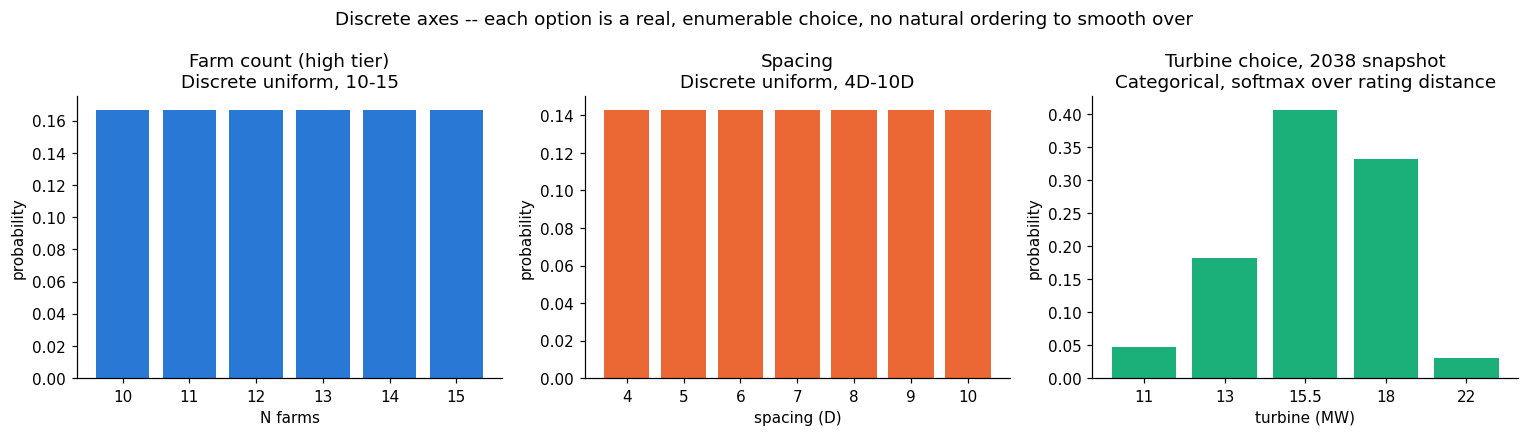

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# farm count, high tier -- discrete uniform, no reason to prefer one count over another
n_vals = np.arange(10, 16)
axes[0].bar(n_vals, np.full(len(n_vals), 1 / len(n_vals)), color=COLORS[0])
axes[0].set_title("Farm count (high tier)\nDiscrete uniform, 10-15")
axes[0].set_xlabel("N farms")

# spacing -- discrete uniform, same reasoning
d_vals = np.arange(4, 11)
axes[1].bar(d_vals, np.full(len(d_vals), 1 / len(d_vals)), color=COLORS[1])
axes[1].set_title("Spacing\nDiscrete uniform, 4D-10D")
axes[1].set_xlabel("spacing (D)")

# turbine choice -- categorical, probabilities from the Gaussian-kernel softmax (2038 snapshot)
RATINGS = np.array([11.0, 13.0, 15.5, 18.0, 22.0])
target = 11.5 + (21.0 - 11.5) * ((2038 - 2026) / (2050 - 2026)) ** 1.0
w = np.exp(-((target - RATINGS) ** 2) / (2 * 2.5 ** 2))
shares = w / w.sum()
axes[2].bar(range(5), shares, color=COLORS[2], tick_label=["11", "13", "15.5", "18", "22"])
axes[2].set_title("Turbine choice, 2038 snapshot\nCategorical, softmax over rating distance")
axes[2].set_xlabel("turbine (MW)")

for ax in axes:
    ax.set_ylabel("probability")
fig.suptitle("Discrete axes -- each option is a real, enumerable choice, no natural ordering to smooth over")
fig.tight_layout()
plt.show()

## 2. Continuous shape axes -- farm timing, climate mode, direction rotation

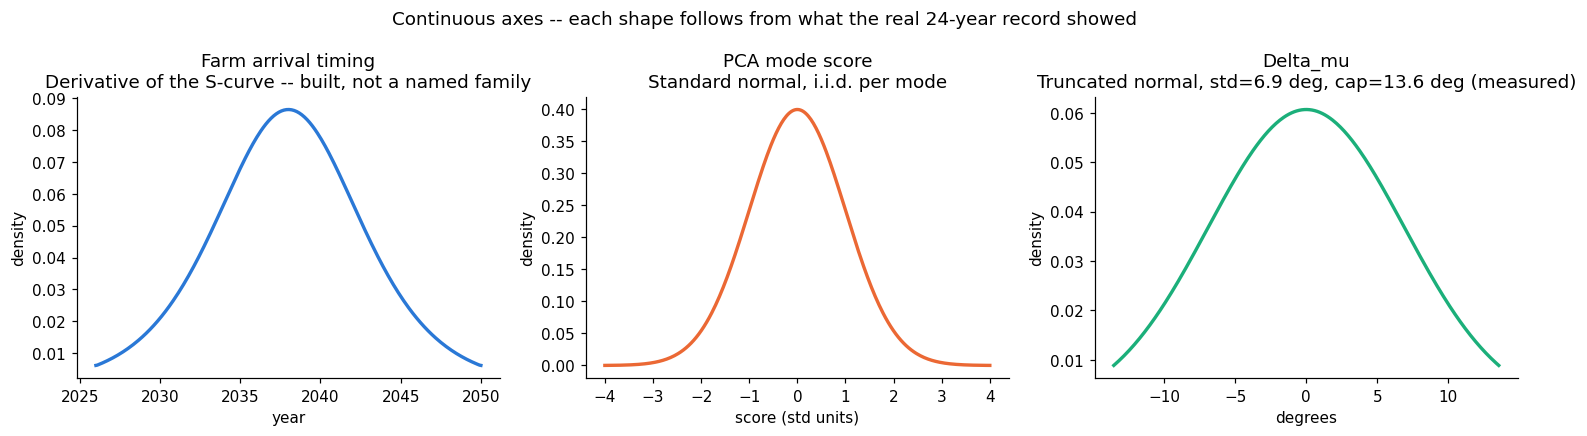

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# farm arrival timing -- density is the derivative of the S-curve, not sampled directly
Y0, Y1, t_mid, s = 2026, 2050, 2038 - 2026, 3.0
T = Y1 - Y0
tt = np.linspace(0, T, 300)
sig = lambda t: 1 / (1 + np.exp(-(t - t_mid) / s))
F = (sig(tt) - sig(0)) / (sig(T) - sig(0))
density = np.gradient(F, tt)
axes[0].plot(tt + Y0, density, color=COLORS[0], linewidth=2.2)
axes[0].set_title("Farm arrival timing\nDerivative of the S-curve -- built, not a named family")
axes[0].set_xlabel("year")

# one PCA climate mode score -- i.i.d. standard normal before eigenvalue scaling
x = np.linspace(-4, 4, 300)
axes[1].plot(x, norm.pdf(x), color=COLORS[1], linewidth=2.2)
axes[1].set_title("PCA mode score\nStandard normal, i.i.d. per mode")
axes[1].set_xlabel("score (std units)")

# Delta_mu -- truncated normal, real calibrated std/cap from the 24-year record
std, cap = vm.DELTA_MU_STD_DEG, vm.DELTA_MU_MAX_DEG
xg = np.linspace(-cap, cap, 300)
a, b = -cap / std, cap / std
axes[2].plot(xg, truncnorm.pdf(xg, a, b, loc=0, scale=std), color=COLORS[2], linewidth=2.2)
axes[2].set_title(f"Delta_mu\nTruncated normal, std={std:.1f} deg, cap={cap:.1f} deg (measured)")
axes[2].set_xlabel("degrees")

for ax in axes:
    ax.set_ylabel("density")
fig.suptitle("Continuous axes -- each shape follows from what the real 24-year record showed")
fig.tight_layout()
plt.show()

## 3. Von Mises perturbation axes -- kappa, pi_m, S_v

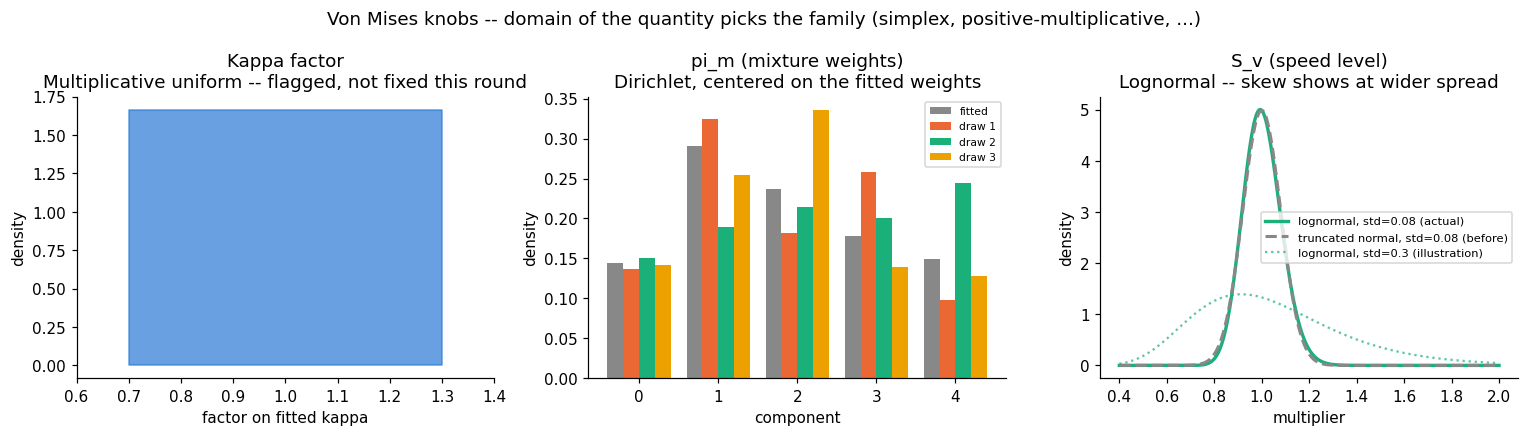

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# kappa factor -- multiplicative uniform, not yet revisited (kept fixed this round)
spread = 0.3
axes[0].fill_between([1 - spread, 1 + spread], [1 / (2 * spread)] * 2, color=COLORS[0], alpha=0.7)
axes[0].set_xlim(1 - spread - 0.1, 1 + spread + 0.1)
axes[0].set_title("Kappa factor\nMultiplicative uniform -- flagged, not fixed this round")
axes[0].set_xlabel("factor on fitted kappa")

# pi_m -- Dirichlet is 5-dimensional, shown as example draws next to the fitted point
draws = [vm.WEIGHTS] + [rng.dirichlet(vm.WEIGHTS * 40.0) for _ in range(3)]
labels = ["fitted"] + [f"draw {i+1}" for i in range(3)]
x = np.arange(5)
width = 0.2
for i, (d, lab) in enumerate(zip(draws, labels)):
    axes[1].bar(x + (i - 1.5) * width, d, width, label=lab,
                color=COLORS[i] if i else "#888888")
axes[1].set_title("pi_m (mixture weights)\nDirichlet, centered on the fitted weights")
axes[1].set_xlabel("component")
axes[1].legend(fontsize=7)

# S_v -- lognormal (fixed) vs the old truncated normal. At the actual calibrated
# std=0.08 the two nearly coincide -- too narrow for the family to matter visually.
# A wider illustrative spread (not what's used) is added just to show the skew that
# the family, not the number, is responsible for.
sv_mean, sv_std = 1.0, 0.08
xg = np.linspace(0.4, 2.0, 400)
axes[2].plot(xg, lognorm.pdf(xg, s=sv_std, scale=sv_mean), color=COLORS[2], linewidth=2.2, label="lognormal, std=0.08 (actual)")
a, b = (0.5 - sv_mean) / sv_std, (1.8 - sv_mean) / sv_std
axes[2].plot(xg, truncnorm.pdf(xg, a, b, loc=sv_mean, scale=sv_std), color="#888888",
             linewidth=2, linestyle="--", label="truncated normal, std=0.08 (before)")
axes[2].plot(xg, lognorm.pdf(xg, s=0.3, scale=sv_mean), color=COLORS[2], linewidth=1.5,
             linestyle=":", alpha=0.7, label="lognormal, std=0.3 (illustration)")
axes[2].set_title("S_v (speed level)\nLognormal -- skew shows at wider spread")
axes[2].set_xlabel("multiplier")
axes[2].legend(fontsize=7.5)

for ax in axes:
    ax.set_ylabel("density")
fig.suptitle("Von Mises knobs -- domain of the quantity picks the family (simplex, positive-multiplicative, ...)")
fig.tight_layout()
plt.show()

## Summary

| Axis | Family | Why |
|---|---|---|
| Farm count, spacing | Discrete uniform | Finite enumerable options, no reason to prefer one |
| Turbine choice | Categorical (softmax weights) | Finite set, year-dependent likelihood |
| Farm arrival timing | Custom (logistic-derived S-curve) | Needs slow-start/plateau shape, no standard family fits both ends |
| PCA climate mode | Normal | Unbounded, symmetric natural variability |
| Delta_mu | Truncated normal | Bounded rotation, calibrated against real year-to-year spread |
| kappa factor | Uniform (multiplicative) | Simple perturbation, not yet revisited -- log-uniform would be the more correct fix |
| pi_m | Dirichlet | Must sum to 1, stay non-negative -- the only distribution built for that domain |
| S_v | Lognormal | Strictly positive multiplicative factor -- decays smoothly, no hard clip needed |

Six different families across ten axes isn't sprawl -- each one is picked to match the mathematical domain of that specific quantity (a simplex needs Dirichlet, a circular quantity needs von Mises/truncated normal, a strictly-positive multiplier needs lognormal). The one still flagged: kappa's uniform perturbation, kept as-is this round since kappa itself is held fixed for the current Delta_mu x spacing x turbine sweep.